# Transformers for Beginners: An Application-Oriented Guide

## 1. Introduction to Transformers

Transformers are a groundbreaking neural network architecture introduced in the paper "Attention Is All You Need" (Vaswani et al., 2017). They have revolutionized the field of Natural Language Processing (NLP) and are now widely used for tasks like text generation, translation, summarization, and more.

The core idea behind Transformers is the **attention mechanism**, which allows the model to weigh the importance of different parts of the input sequence when processing each element. Unlike traditional recurrent neural networks (RNNs), Transformers process sequences in parallel, making them much faster and more efficient for long sequences.

### Key Components:
*   **Self-Attention**: Allows the model to look at other words in the input sequence to get a better understanding of the context of each word.
*   **Multi-Head Attention**: Runs the attention mechanism multiple times in parallel to capture different types of relationships.
*   **Feed-Forward Networks**: Standard neural network layers applied independently to each position.
*   **Positional Encodings**: Since Transformers don't have inherent sequential processing, positional encodings are added to the input embeddings to provide information about the relative or absolute position of tokens in the sequence.
*   **Encoder-Decoder Structure**: The original Transformer consists of an encoder stack and a decoder stack, each with multiple identical layers.
    *   **Encoder**: Processes the input sequence and transforms it into a rich representation.
    *   **Decoder**: Takes the encoder's output and generates the output sequence, often attending to both the encoder's output and its own previously generated tokens.

## 2. Setting Up Hugging Face Transformers

The Hugging Face `transformers` library provides thousands of pre-trained models to perform tasks on texts, images, audio, and more. It offers a high-level API that makes it easy to download, fine-tune, and use state-of-the-art models.

First, let's install the necessary library.

In [ ]:
# Install the Hugging Face Transformers library
!pip install transformers sentence-transformers -q

Once installed, we can start using the `pipeline` function, which is the easiest way to use pre-trained models for inference on a wide range of tasks.

In [ ]:
# ============================================================================
# SUPPORTED_TASKS
# ----------------------------------------------------------------------------
# - A dictionary containing the core built-in pipeline tasks supported by
#   Hugging Face Transformers.
# - Stores metadata such as:
#     * Pipeline implementation class
#     * PyTorch model class
#     * TensorFlow model class
#     * Default model mappings
# - Primarily used internally by the Transformers library.
# - Usually contains only the canonical/internal task names.
# - Example:
#     sentiment-analysis -> text-classification
#     ner                -> token-classification
#   Therefore aliases like "sentiment-analysis" and "ner" may not appear here.
# ============================================================================

from transformers.pipelines import SUPPORTED_TASKS

print(f"Total tasks: {len(SUPPORTED_TASKS)}")
print("*"*70)
for task in SUPPORTED_TASKS:
    print(task)
print("*"*70)

Total tasks: 24
**********************************************************************
audio-classification
automatic-speech-recognition
text-to-audio
feature-extraction
text-classification
token-classification
table-question-answering
document-question-answering
fill-mask
text-generation
zero-shot-classification
zero-shot-image-classification
zero-shot-audio-classification
image-classification
image-feature-extraction
image-segmentation
image-text-to-text
object-detection
zero-shot-object-detection
depth-estimation
video-classification
mask-generation
keypoint-matching
any-to-any
**********************************************************************


In [ ]:
# ============================================================================
# PIPELINE_REGISTRY
# ----------------------------------------------------------------------------
# - A registry object that manages all available pipelines.
# - Used by the pipeline() API to resolve and instantiate pipelines.
# - Includes:
#     * Built-in tasks
#     * User-friendly aliases
#     * Custom registered pipelines
# - More dynamic and extensible than SUPPORTED_TASKS.
# - Often shows aliases such as:
#     sentiment-analysis
#     ner
#     question-answering
# - Supports custom pipeline registration through:
#     PIPELINE_REGISTRY.register_pipeline(...)
# ============================================================================
from transformers.pipelines import PIPELINE_REGISTRY

for task in sorted(PIPELINE_REGISTRY.get_supported_tasks()):
    print(task)

any-to-any
audio-classification
automatic-speech-recognition
depth-estimation
document-question-answering
feature-extraction
fill-mask
image-classification
image-feature-extraction
image-segmentation
image-text-to-text
keypoint-matching
mask-generation
ner
object-detection
sentiment-analysis
table-question-answering
text-classification
text-generation
text-to-audio
text-to-speech
token-classification
video-classification
zero-shot-audio-classification
zero-shot-classification
zero-shot-image-classification
zero-shot-object-detection


## 3. Using Hugging Face Pipelines for Inference

The `pipeline` function is the easiest way to use pre-trained models for inference. It abstracts away the complexities of tokenization, model loading, and output post-processing.

### 3.1 Text Classification

Text classification involves assigning a label or category to a given text. Let's classify some movie reviews as positive or negative.

In [21]:
from transformers import pipeline

# Load a pre-trained sentiment analysis pipeline
classifier = pipeline("sentiment-analysis")

# Classify some texts
texts = [
    "This movie is absolutely fantastic! I loved every minute of it.",
    "The plot was convoluted and the acting was terrible.",
    "It's a decent film, nothing groundbreaking but enjoyable."
]

for text in texts:
    result = classifier(text)
    print(f"Text: {text}\nSentiment: {result[0]['label']}, Score: {result[0]['score']:.2f}\n")


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Text: This movie is absolutely fantastic! I loved every minute of it.
Sentiment: POSITIVE, Score: 1.00

Text: The plot was convoluted and the acting was terrible.
Sentiment: NEGATIVE, Score: 1.00

Text: It's a decent film, nothing groundbreaking but enjoyable.
Sentiment: POSITIVE, Score: 1.00



In [ ]:
print(classifier.model.name_or_path)

distilbert/distilbert-base-uncased-finetuned-sst-2-english


### 3.2 Question Answering

Question Answering models can extract answers from a given context. Let's try to answer a question based on a provided text.

In [26]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import torch

model_name = "distilbert-base-cased-distilled-squad"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model     = AutoModelForQuestionAnswering.from_pretrained(model_name)

context  = "The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France..."
question = "Who designed the Eiffel Tower?"

inputs = tokenizer(question, context, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

start = outputs.start_logits.argmax()
end   = outputs.end_logits.argmax() + 1
answer = tokenizer.convert_tokens_to_string(
    tokenizer.convert_ids_to_tokens(inputs["input_ids"][0][start:end])
)

print(f"Answer: {answer}")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Answer: Champ de Mars in Paris, France.


### 3.3 Text Generation

Generative models can create new text based on a given prompt. Let's see how a text generation pipeline works.

In [ ]:
text_generator = pipeline("text-generation", model="gpt2")

prompt = "Once upon a time, in a land far, far away, there was a dragon"

generated_text = text_generator(prompt, max_length=50, num_return_sequences=1)
print(f"Prompt: {prompt}\nGenerated Text: {generated_text[0]['generated_text']}\n")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_

Prompt: Once upon a time, in a land far, far away, there was a dragon
Generated Text: Once upon a time, in a land far, far away, there was a dragon. It flew straight at Me. Me was a dragon, and Me was a dragon. The dragon was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was going to fly, and Me was

In [ ]:
print(text_generator.model.name_or_path)

gpt2


## 4. Encoder-Only, Decoder-Only, and Encoder-Decoder Transformers

Transformers can be broadly categorized into three types based on their architecture:

*   **Encoder-Only Models** (e.g., BERT, RoBERTa): These models are designed to understand and encode the input text. They are excellent for tasks that require a deep understanding of the input, such as sentiment analysis, classification, and named entity recognition.
    *   **Analogy**: Think of them as expert readers who can understand complex texts and summarize their main points, but they don't generate new content.

*   **Decoder-Only Models** (e.g., GPT, LLaMA): These models are designed for text generation. They take a prompt and predict the next token in a sequence, effectively generating new text. They are used for tasks like creative writing, chatbots, and code generation.
    *   **Analogy**: These are like creative writers who can continue a story or generate new ideas based on a given starting point.

*   **Encoder-Decoder Models** (e.g., T5, BART): These models combine both an encoder and a decoder. The encoder processes the input, and the decoder generates an output based on the encoder's representation. They are ideal for sequence-to-sequence tasks like machine translation, summarization, and question answering where an output sequence is generated from an input sequence.
    *   **Analogy**: Imagine a translator who first understands the original language (encoder) and then translates it into another language (decoder).

## 5. Sentence Transformers for Semantic Similarity

**Sentence Transformers** (or `sentence-transformers`) are a specialized type of Transformer model that produces semantically meaningful sentence embeddings. This means that sentences with similar meanings will have embeddings that are close to each other in vector space.

### Motivation:

Traditional Transformer models (like BERT) are great for many tasks, but generating sentence embeddings directly from their output (e.g., using the `[CLS]` token embedding) doesn't always yield the best results for semantic similarity. This is because these models are often trained for classification or token-level tasks, not specifically for producing dense sentence representations that capture overall meaning well.

Sentence Transformers are fine-tuned or trained specifically to produce high-quality sentence embeddings, making them ideal for tasks such as:

*   **Semantic Search**: Finding documents or passages relevant to a query based on meaning.
*   **Clustering**: Grouping similar sentences or documents together.
*   **Paraphrase Mining**: Identifying sentences that convey the same meaning.
*   **Plagiarism Detection**: Comparing text segments for similarity.

Let's demonstrate how to use a Sentence Transformer to find the similarity between sentences.

In [ ]:
from sentence_transformers import SentenceTransformer, util
import torch

# Load a pre-trained Sentence Transformer model
# This model maps sentences and paragraphs to a 768-dimensional dense vector space
model = SentenceTransformer('all-MiniLM-L6-v2')

# Define some sentences
sentences = [
    "The cat sat on the mat.",
]

# Encode the sentences into embeddings
embeddings = model.encode(sentences[0], convert_to_tensor=True)

embeddings

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

tensor([ 1.3024e-01, -1.5773e-02, -3.6717e-02,  5.7986e-02, -5.9792e-02,
         3.3054e-02,  3.0124e-02,  2.8927e-02, -1.8605e-02,  5.5297e-02,
        -2.8155e-02,  6.9760e-02,  3.9666e-02,  2.5935e-02, -5.5140e-02,
        -5.2253e-02, -5.3444e-02, -3.6682e-02,  6.0816e-02,  3.7069e-02,
        -3.0382e-02, -1.3053e-02,  3.0966e-02, -6.1744e-02, -5.1799e-02,
         7.6194e-02, -2.9812e-02, -5.2309e-02,  4.2482e-02, -6.3590e-03,
        -6.6263e-02,  2.2615e-03, -2.6349e-02,  5.5925e-02,  1.7411e-02,
        -9.1676e-02,  1.4393e-02, -7.2229e-02,  4.3794e-02,  2.0902e-02,
         8.7200e-02, -3.2806e-03, -9.0017e-03, -5.6538e-02,  2.6365e-02,
         1.4662e-02,  1.0639e-01, -1.0837e-01,  5.4525e-02, -1.6214e-02,
        -7.2537e-02,  5.6607e-02,  5.9725e-02,  3.0389e-02, -1.1540e-01,
        -4.6508e-02,  8.9576e-02, -4.8455e-02, -3.2641e-03, -5.6871e-02,
        -3.2220e-02,  3.0522e-02,  8.7764e-02,  7.7693e-02,  5.4544e-02,
        -5.5859e-02, -6.9086e-02, -1.2018e-02,  1.1

In [ ]:
print("Sentence embeddings length:",len(embeddings))

Sentence embeddings length: 384


In [ ]:
# Define some sentences
sentences = [
    "The cat sat on the mat.",
    "The cat sat on the mat.",
    "A feline was resting on the rug.",
    "The dog chased the ball.",
    "I am learning about natural language processing."
]

# Encode the sentences into embeddings
embeddings = model.encode(sentences, convert_to_tensor=True)

# Calculate cosine similarity between all pairs of sentences
cosine_scores = util.cos_sim(embeddings, embeddings)

print("Sentence Similarity Scores:")
for i in range(len(sentences)):
    for j in range(i + 1, len(sentences)):
        print(f"Sentence 1: '{sentences[i]}'\nSentence 2: '{sentences[j]}'\nSimilarity: {cosine_scores[i][j]:.4f}\n")

Sentence Similarity Scores:
Sentence 1: 'The cat sat on the mat.'
Sentence 2: 'The cat sat on the mat.'
Similarity: 1.0000

Sentence 1: 'The cat sat on the mat.'
Sentence 2: 'A feline was resting on the rug.'
Similarity: 0.5631

Sentence 1: 'The cat sat on the mat.'
Sentence 2: 'The dog chased the ball.'
Similarity: 0.1213

Sentence 1: 'The cat sat on the mat.'
Sentence 2: 'I am learning about natural language processing.'
Similarity: 0.0173

Sentence 1: 'The cat sat on the mat.'
Sentence 2: 'A feline was resting on the rug.'
Similarity: 0.5631

Sentence 1: 'The cat sat on the mat.'
Sentence 2: 'The dog chased the ball.'
Similarity: 0.1213

Sentence 1: 'The cat sat on the mat.'
Sentence 2: 'I am learning about natural language processing.'
Similarity: 0.0173

Sentence 1: 'A feline was resting on the rug.'
Sentence 2: 'The dog chased the ball.'
Similarity: 0.1957

Sentence 1: 'A feline was resting on the rug.'
Sentence 2: 'I am learning about natural language processing.'
Similarity: 0.

## 6. Selecting Appropriate Transformer Variants for Tasks

Choosing the right Transformer model depends heavily on your specific task. Here's a general guide:

*   **Classification (e.g., sentiment analysis, spam detection)**:
    *   **Best Fit**: Encoder-only models (e.g., BERT, RoBERTa, DistilBERT).
    *   **Why**: They excel at understanding the full context of a sentence to make a prediction about it.
    *   **Hugging Face Pipeline**: `pipeline("sentiment-analysis")`, `pipeline("zero-shot-classification")`

*   **Similarity (e.g., semantic search, paraphrasing, clustering)**:
    *   **Best Fit**: Sentence Transformers (specialized encoder models like `all-MiniLM-L6-v2`).
    *   **Why**: They are specifically trained to produce semantically rich sentence embeddings.
    *   **Hugging Face Library**: `SentenceTransformer` from `sentence_transformers`

*   **Generation (e.g., creative writing, chatbot responses, code generation)**:
    *   **Best Fit**: Decoder-only models (e.g., GPT-2, GPT-Neo, LLaMA-based models).
    *   **Why**: They are designed to predict the next word in a sequence, generating coherent and contextually relevant text.
    *   **Hugging Face Pipeline**: `pipeline("text-generation")`

*   **Summarization (e.g., abstractive, extractive)**:
    *   **Best Fit**: Encoder-decoder models (e.g., BART, T5, Pegasus).
    *   **Why**: Similar to translation, an input sequence (long text) is mapped to an output sequence (summary).
    *   **Hugging Face Pipeline**: `pipeline("summarization")`

*   **Question Answering (e.g., extractive QA, generative QA)**:
    *   **Best Fit**: Encoder-only for extractive (e.g., BERT, RoBERTa), Encoder-decoder for generative (e.g., T5).
    *   **Why**: Extractive models find the answer span in the context. Generative models generate an answer from scratch.
    *   **Hugging Face Pipeline**: `pipeline("question-answering")`

In [ ]:
from sentence_transformers import SentenceTransformer, util
import torch
from sklearn.cluster import KMeans
import numpy as np

# Load the Sentence Transformer model (already used in Section 5)
# This model maps sentences and paragraphs to a 768-dimensional dense vector space
model = SentenceTransformer('all-MiniLM-L6-v2')

# Define a new set of sentences for clustering
texts_for_clustering = [
    "The quick brown fox jumps over the lazy dog.",
    "A fast brown canine leaps over a sluggish hound.",
    "The cat is sleeping peacefully on the couch.",
    "My feline friend is napping on the sofa.",
    "The sun is shining brightly today.",
    "It's a beautiful day with clear skies and sunshine."
]

# Encode the sentences into embeddings
# convert_to_tensor=False to get numpy arrays, which KMeans expects
embeddings_for_clustering = model.encode(texts_for_clustering, convert_to_tensor=False)

# Perform K-Means clustering
# Let's assume we want to find 3 clusters for this example
num_clusters = 3
kmeans_model = KMeans(n_clusters=num_clusters, random_state=42, n_init=10) # n_init is specified for modern sklearn versions
kmeans_model.fit(embeddings_for_clustering)
cluster_assignment = kmeans_model.labels_

print("Text Clustering Results:")
for i, text in enumerate(texts_for_clustering):
    print(f"Text: '{text}' \t\t Cluster: {cluster_assignment[i]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Text Clustering Results:
Text: 'The quick brown fox jumps over the lazy dog.' 		 Cluster: 2
Text: 'A fast brown canine leaps over a sluggish hound.' 		 Cluster: 2
Text: 'The cat is sleeping peacefully on the couch.' 		 Cluster: 0
Text: 'My feline friend is napping on the sofa.' 		 Cluster: 0
Text: 'The sun is shining brightly today.' 		 Cluster: 1
Text: 'It's a beautiful day with clear skies and sunshine.' 		 Cluster: 1


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from collections import defaultdict

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Sample texts
texts_for_clustering = [
    "The quick brown fox jumps over the lazy dog.",
    "A fast brown canine leaps over a sluggish hound.",
    "The cat is sleeping peacefully on the couch.",
    "My feline friend is napping on the sofa.",
    "The sun is shining brightly today.",
    "It's a beautiful day with clear skies and sunshine."
]

# Generate embeddings
embeddings = model.encode(
    texts_for_clustering,
    convert_to_tensor=False
)

# KMeans Clustering
num_clusters = 3
kmeans = KMeans(
    n_clusters=num_clusters,
    random_state=42,
    n_init=10
)

kmeans.fit(embeddings)

cluster_labels = kmeans.labels_

# Group texts by cluster
clustered_texts = defaultdict(list)

for text, cluster_id in zip(texts_for_clustering, cluster_labels):
    clustered_texts[cluster_id].append(text)

# Print cluster-wise texts
print("=" * 60)
print("Cluster-wise Text Grouping")
print("=" * 60)

for cluster_id, texts in clustered_texts.items():
    print(f"\nCluster {cluster_id}")
    print("-" * 40)

    for idx, text in enumerate(texts, start=1):
        print(f"{idx}. {text}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Cluster-wise Text Grouping

Cluster 2
----------------------------------------
1. The quick brown fox jumps over the lazy dog.
2. A fast brown canine leaps over a sluggish hound.

Cluster 0
----------------------------------------
1. The cat is sleeping peacefully on the couch.
2. My feline friend is napping on the sofa.

Cluster 1
----------------------------------------
1. The sun is shining brightly today.
2. It's a beautiful day with clear skies and sunshine.


In [ ]:
# ══════════════════════════════════════════════════
# Named Entity Recognition (NER)
# Model: dslim/bert-base-NER
# Finds: PER (people), ORG (organizations), LOC (locations), MISC
# ══════════════════════════════════════════════════
ner = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple"   # merge sub-word tokens
)

texts = [
    "Sundar Pichai is the CEO of Google, which is headquartered in Mountain View, California.",
    "The FIFA World Cup 2026 will be held in the United States, Canada, and Mexico.",
    "Elon Musk founded SpaceX in 2002 and acquired Twitter, renaming it to X.",
]

entity_icons = {"PER": "👤", "ORG": "🏢", "LOC": "📍", "MISC": "🔖"}

for text in texts:
    entities = ner(text)
    print(f"\n📝 {text}")
    print(f"  {'Type':6s}  {'Entity':25s}  Confidence")
    print(f"  {'─'*6}  {'─'*25}  {'─'*10}")
    for e in entities:
        icon = entity_icons.get(e['entity_group'], '🔖')
        print(f"  {icon} {e['entity_group']:4s}  {e['word']:25s}  {e['score']:.2%}")

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


📝 Sundar Pichai is the CEO of Google, which is headquartered in Mountain View, California.
  Type    Entity                     Confidence
  ──────  ─────────────────────────  ──────────
  👤 PER   Sundar Pichai              99.19%
  🏢 ORG   Google                     99.89%
  📍 LOC   Mountain View              99.77%
  📍 LOC   California                 99.92%

📝 The FIFA World Cup 2026 will be held in the United States, Canada, and Mexico.
  Type    Entity                     Confidence
  ──────  ─────────────────────────  ──────────
  🔖 MISC  FIFA World Cup 2026        91.35%
  📍 LOC   United States              99.95%
  📍 LOC   Canada                     99.98%
  📍 LOC   Mexico                     99.98%

📝 Elon Musk founded SpaceX in 2002 and acquired Twitter, renaming it to X.
  Type    Entity                     Confidence
  ──────  ─────────────────────────  ──────────
  🏢 ORG   Elon                       88.68%
  👤 PER   Mu                         56.98%
  🏢 ORG   ##sk        

## 7. Text Summarization

Summarization condenses a long passage into a shorter version while retaining the key information.

**Model type used:** Encoder-Decoder (e.g., `facebook/bart-large-cnn`, `t5-small`)

- The **encoder** reads and understands the full article.
- The **decoder** generates a shorter summary in its own words (abstractive summarization).

**Why encoder-decoder?**
The model must both *comprehend* the input (encoder) and *produce new text* (decoder) — a job neither encoder-only nor decoder-only architectures do well on their own.

**Real-world uses:** News digests, legal document summaries, meeting notes, research paper abstracts.


In [ ]:
from transformers import BartForConditionalGeneration, BartTokenizer

# ── Load BART model and tokenizer directly (no pipeline needed) ───────────────
# facebook/bart-large-cnn is fine-tuned on CNN/DailyMail news articles.
# It produces abstractive summaries (generates new sentences, not just extracts).
# We bypass pipeline() entirely since this transformers version does not support
# the "summarization" or "text2text-generation" pipeline tasks.
model_name = "facebook/bart-large-cnn"
tokenizer  = BartTokenizer.from_pretrained(model_name)
model      = BartForConditionalGeneration.from_pretrained(model_name)

# ── Input: a longer article excerpt ──────────────────────────────────────────
article = (
    "Artificial intelligence is transforming every industry, from healthcare to finance. "
    "In healthcare, AI models can now detect cancers in medical images with accuracy "
    "comparable to experienced radiologists. Financial institutions use AI to detect fraud "
    "in real time, saving billions of dollars annually. In education, adaptive learning "
    "platforms powered by AI personalise study plans for each student based on their "
    "performance. Meanwhile, autonomous vehicles are being tested on public roads in several "
    "countries. Despite these advancements, concerns about job displacement, data privacy, "
    "and algorithmic bias continue to be debated by researchers, policymakers, and ethicists."
)

# ── Tokenize the input article ────────────────────────────────────────────────
# truncation=True  : cuts input if it exceeds the model's max token limit (1024)
# return_tensors   : returns PyTorch tensors ready for model.generate()
inputs = tokenizer(
    article,
    return_tensors="pt",
    truncation=True,
    max_length=1024
)

# ── Generate the summary ──────────────────────────────────────────────────────
# max_length   : maximum tokens in the generated summary
# min_length   : ensures the summary is not too short
# length_penalty > 1.0 : encourages longer outputs
# num_beams    : beam search width — higher = better quality but slower
# early_stopping : stop beam search when all beams reach the EOS token
summary_ids = model.generate(
    inputs["input_ids"],
    max_length=80,
    min_length=25,
    length_penalty=2.0,
    num_beams=4,
    early_stopping=True
)

# ── Decode the generated token IDs back to a string ──────────────────────────
summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print("Original Article:")
print(article)
print()
print("Generated Summary:")
print(summary)
print()
print("Model:", model_name)

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Original Article:
Artificial intelligence is transforming every industry, from healthcare to finance. In healthcare, AI models can now detect cancers in medical images with accuracy comparable to experienced radiologists. Financial institutions use AI to detect fraud in real time, saving billions of dollars annually. In education, adaptive learning platforms powered by AI personalise study plans for each student based on their performance. Meanwhile, autonomous vehicles are being tested on public roads in several countries. Despite these advancements, concerns about job displacement, data privacy, and algorithmic bias continue to be debated by researchers, policymakers, and ethicists.

Generated Summary:
Artificial intelligence is transforming every industry, from healthcare to finance. In healthcare, AI models can now detect cancers in medical images with accuracy comparable to experienced radiologists. Financial institutions use AI to detect fraud in real time, saving billions of dol

## 8. Zero-Shot Classification

Zero-shot classification lets you classify text into **categories that the model was never explicitly trained on**.
You supply the candidate labels at inference time — no labelled training data required.

**Model type used:** Encoder-only / Encoder-Decoder (e.g., `facebook/bart-large-mnli`)

The model is trained on Natural Language Inference (NLI): given a premise and a hypothesis, decide if the hypothesis is *entailed*, *contradicted*, or *neutral*. At inference time the pipeline rephrases each candidate label as a hypothesis and picks the one with the highest entailment score.

**Why is this powerful?**
You can apply a single model to completely new classification problems without any fine-tuning — just describe your labels in plain English.

**Real-world uses:** Content moderation, customer-support routing, intent detection, news categorisation.


In [ ]:
from transformers import pipeline

# ── Load the zero-shot classification pipeline ────────────────────────────────
# facebook/bart-large-mnli is trained on the MultiNLI dataset.
# The pipeline internally converts each candidate_label into an NLI hypothesis.
zero_shot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# ── Example 1: News topic detection ──────────────────────────────────────────
text_1 = (
    "The central bank raised interest rates by 50 basis points to combat rising inflation, "
    "sending stock markets lower as investors worried about slower economic growth."
)

candidate_labels_1 = ["politics", "sports", "finance", "technology", "entertainment"]

result_1 = zero_shot(text_1, candidate_labels=candidate_labels_1)

print("Text:", text_1)
print()
print(f"{'Label':15s}  Score")
print("-" * 30)
for label, score in zip(result_1["labels"], result_1["scores"]):
    bar = "█" * int(score * 30)
    print(f"{label:15s}  {score:.4f}  {bar}")


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Text: The central bank raised interest rates by 50 basis points to combat rising inflation, sending stock markets lower as investors worried about slower economic growth.

Label            Score
------------------------------
finance          0.7865  ███████████████████████
entertainment    0.0850  ██
sports           0.0470  █
politics         0.0448  █
technology       0.0367  █


In [ ]:
# ── Example 2: Customer support intent routing ────────────────────────────────
texts_2 = [
    "My internet has been down for two days and I need it fixed immediately.",
    "I want to cancel my subscription and get a refund for last month.",
    "Can you help me understand how to set up two-factor authentication on my account?",
]

intents = ["technical support", "billing and refunds", "account management"]

print("Customer Support Intent Detection")
print("=" * 60)
for text in texts_2:
    result = zero_shot(text, candidate_labels=intents)
    top_intent = result["labels"][0]
    top_score  = result["scores"][0]
    print(f"\nMessage : {text}")
    print(f"Routing  : {top_intent}  (confidence: {top_score:.2%})")


Customer Support Intent Detection

Message : My internet has been down for two days and I need it fixed immediately.
Routing  : technical support  (confidence: 88.26%)

Message : I want to cancel my subscription and get a refund for last month.
Routing  : billing and refunds  (confidence: 58.99%)

Message : Can you help me understand how to set up two-factor authentication on my account?
Routing  : account management  (confidence: 62.84%)


## 9. Machine Translation

Machine Translation converts text from one natural language to another.

**Model type used:** Encoder-Decoder (e.g., `Helsinki-NLP/opus-mt-en-fr`)

The encoder reads the source-language sentence and produces a context-rich representation.
The decoder generates the target-language sentence one token at a time, attending to the encoder's output at each step.

**Helsinki-NLP OPUS-MT** models are a collection of lightweight seq2seq Transformer models trained on the [OPUS](https://opus.nlpl.eu/) parallel corpora covering hundreds of language pairs.

**Real-world uses:** Document localisation, multilingual chatbots, cross-language search, international customer support.


In [ ]:
from transformers import MarianMTModel, MarianTokenizer

# ── Load Helsinki-NLP MarianMT models directly (no pipeline needed) ───────────
# MarianMT is the underlying architecture for all Helsinki-NLP/opus-mt models.
# We skip pipeline() entirely and use the tokenizer + model directly,
# which works regardless of the transformers version installed.

def load_translator(src_lang, tgt_lang):
    """Load a Helsinki-NLP MarianMT model for a given language pair."""
    model_name = f"Helsinki-NLP/opus-mt-{src_lang}-{tgt_lang}"
    tokenizer  = MarianTokenizer.from_pretrained(model_name)
    model      = MarianMTModel.from_pretrained(model_name)
    return tokenizer, model

def translate(sentences, tokenizer, model):
    """Translate a list of sentences and return translated strings."""
    # Tokenize: pad and truncate to model's max length
    inputs = tokenizer(
        sentences,
        return_tensors="pt",
        padding=True,
        truncation=True
    )
    # Generate translated token IDs
    translated_ids = model.generate(**inputs)
    # Decode token IDs back to strings, skipping special tokens
    return tokenizer.batch_decode(translated_ids, skip_special_tokens=True)

english_sentences = [
    "Transformers have revolutionised the field of natural language processing.",
    "The weather is beautiful today.",
    "Artificial intelligence is changing the world rapidly.",
]

# ── English → French ──────────────────────────────────────────────────────────
tokenizer_fr, model_fr = load_translator("en", "fr")

print("English → French Translation")
print("=" * 60)
translations_fr = translate(english_sentences, tokenizer_fr, model_fr)
for en, fr in zip(english_sentences, translations_fr):
    print(f"  EN: {en}")
    print(f"  FR: {fr}")
    print()

# ── English → German ──────────────────────────────────────────────────────────
tokenizer_de, model_de = load_translator("en", "de")

print("English → German Translation")
print("=" * 60)
translations_de = translate(english_sentences, tokenizer_de, model_de)
for en, de in zip(english_sentences, translations_de):
    print(f"  EN: {en}")
    print(f"  DE: {de}")
    print()

print("EN→FR model:", model_fr.config.name_or_path)
print("EN→DE model:", model_de.config.name_or_path)

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.34M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


...

pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

English → German Translation
  EN: Transformers have revolutionised the field of natural language processing.
  DE: Transformer haben das Feld der natürlichen Sprachverarbeitung revolutioniert.

  EN: The weather is beautiful today.
  DE: Das Wetter ist heute schön.

  EN: Artificial intelligence is changing the world rapidly.
  DE: Künstliche Intelligenz verändert die Welt rasant.

EN→FR model: Helsinki-NLP/opus-mt-en-fr
EN→DE model: Helsinki-NLP/opus-mt-en-de


In [ ]:
# ── Model info ────────────────────────────────────────────────────────────────
print("EN→FR model:", translator_en_fr.model.name_or_path)
print("EN→DE model:", translator_en_de.model.name_or_path)


## 10. Fill-Mask (Masked Language Modelling)

Fill-mask is the original pre-training task for encoder-only models like BERT.
A word in the sentence is replaced with a special `[MASK]` token and the model predicts what word belongs there.

**Model type used:** Encoder-Only (e.g., `bert-base-uncased`, `roberta-base`)

Unlike text generation (which predicts the *next* token), fill-mask predicts a *missing* token using **bidirectional context** — it looks at words both before and after the mask. This is why encoder-only models are so powerful for understanding tasks.

**Real-world uses:**
- Auto-complete and spell-correction
- Understanding how language models "think" about word choices
- Probing model biases
- Data augmentation (replacing words with plausible alternatives)


In [ ]:
from transformers import pipeline

# ── Load the fill-mask pipeline ───────────────────────────────────────────────
# bert-base-uncased uses [MASK] as the mask token.
# roberta-base uses <mask> — the pipeline handles this automatically.
fill_masker = pipeline("fill-mask", model="bert-base-uncased")

# ── Example 1: Factual knowledge ─────────────────────────────────────────────
masked_sentence_1 = "The capital of France is [MASK]."

print("Sentence:", masked_sentence_1)
print()
results_1 = fill_masker(masked_sentence_1)

print(f"{'Token':15s}  {'Score':>7s}")
print("-" * 26)
for r in results_1:
    bar = "█" * int(r["score"] * 40)
    print(f"{r['token_str']:15s}  {r['score']:>7.4f}  {bar}")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Sentence: The capital of France is [MASK].

Token              Score
--------------------------
paris             0.4168  ████████████████
lille             0.0714  ██
lyon              0.0634  ██
marseille         0.0444  █
tours             0.0303  █


In [ ]:
# ── Example 2: Contextual word choice ────────────────────────────────────────
masked_sentences = [
    "The doctor examined the [MASK] carefully before making a diagnosis.",
    "She opened the [MASK] and started reading the first chapter.",
    "The [MASK] scored a goal in the final minute of the match.",
]

for sentence in masked_sentences:
    print(f"Sentence : {sentence}")
    results = fill_masker(sentence, top_k=3)  # top_k: return top 3 predictions
    for r in results:
        print(f"  [{r['token_str']:12s}]  score={r['score']:.4f}  →  {r['sequence']}")
    print()


Sentence : The doctor examined the [MASK] carefully before making a diagnosis.
  [patient     ]  score=0.1512  →  the doctor examined the patient carefully before making a diagnosis.
  [wound       ]  score=0.1138  →  the doctor examined the wound carefully before making a diagnosis.
  [body        ]  score=0.0500  →  the doctor examined the body carefully before making a diagnosis.

Sentence : She opened the [MASK] and started reading the first chapter.
  [book        ]  score=0.8110  →  she opened the book and started reading the first chapter.
  [journal     ]  score=0.0465  →  she opened the journal and started reading the first chapter.
  [magazine    ]  score=0.0209  →  she opened the magazine and started reading the first chapter.

Sentence : The [MASK] scored a goal in the final minute of the match.
  [team        ]  score=0.0623  →  the team scored a goal in the final minute of the match.
  [hosts       ]  score=0.0389  →  the hosts scored a goal in the final minute of the mat

In [ ]:
# ── Model info ────────────────────────────────────────────────────────────────
print("Model used:", fill_masker.model.name_or_path)


Model used: bert-base-uncased


## 11. Image Classification with Vision Transformers (ViT)

Transformers are not limited to text. **Vision Transformers (ViT)**, introduced by Dosovitskiy et al. (2020), apply the same self-attention mechanism to images.

### How ViT Works
1. The image is split into fixed-size **patches** (e.g., 16×16 pixels).
2. Each patch is linearly projected into an embedding vector — analogous to a word token.
3. A learnable `[CLS]` (classification) token is prepended to the sequence.
4. Positional embeddings are added so the model knows the spatial layout.
5. The sequence is passed through standard Transformer encoder layers.
6. The final `[CLS]` token embedding is fed into a classification head.

**Key insight:** By treating image patches as tokens, ViT can leverage the same powerful attention mechanism that made BERT and GPT successful in NLP.

**Real-world uses:** Medical image diagnosis, autonomous driving perception, content moderation, product search.

```
Input Image
    │
    ▼
┌─────────────────────────────┐
│  Split into 16×16 patches   │
│  [P1][P2][P3] ... [Pn]      │
└─────────────────────────────┘
    │
    ▼
┌─────────────────────────────┐
│  Linear Patch Embedding     │
│  + Positional Embedding     │
│  + [CLS] Token              │
└─────────────────────────────┘
    │
    ▼
┌─────────────────────────────┐
│  Transformer Encoder Stack  │
│  (Multi-Head Self-Attention │
│   + Feed-Forward Layers)    │
└─────────────────────────────┘
    │
    ▼
┌─────────────────────────────┐
│  [CLS] → Classification Head│
│  → Predicted Label          │
└─────────────────────────────┘
```


In [ ]:
# ── Install Pillow if needed (usually pre-installed) ─────────────────────────
# !pip install Pillow requests --quiet


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

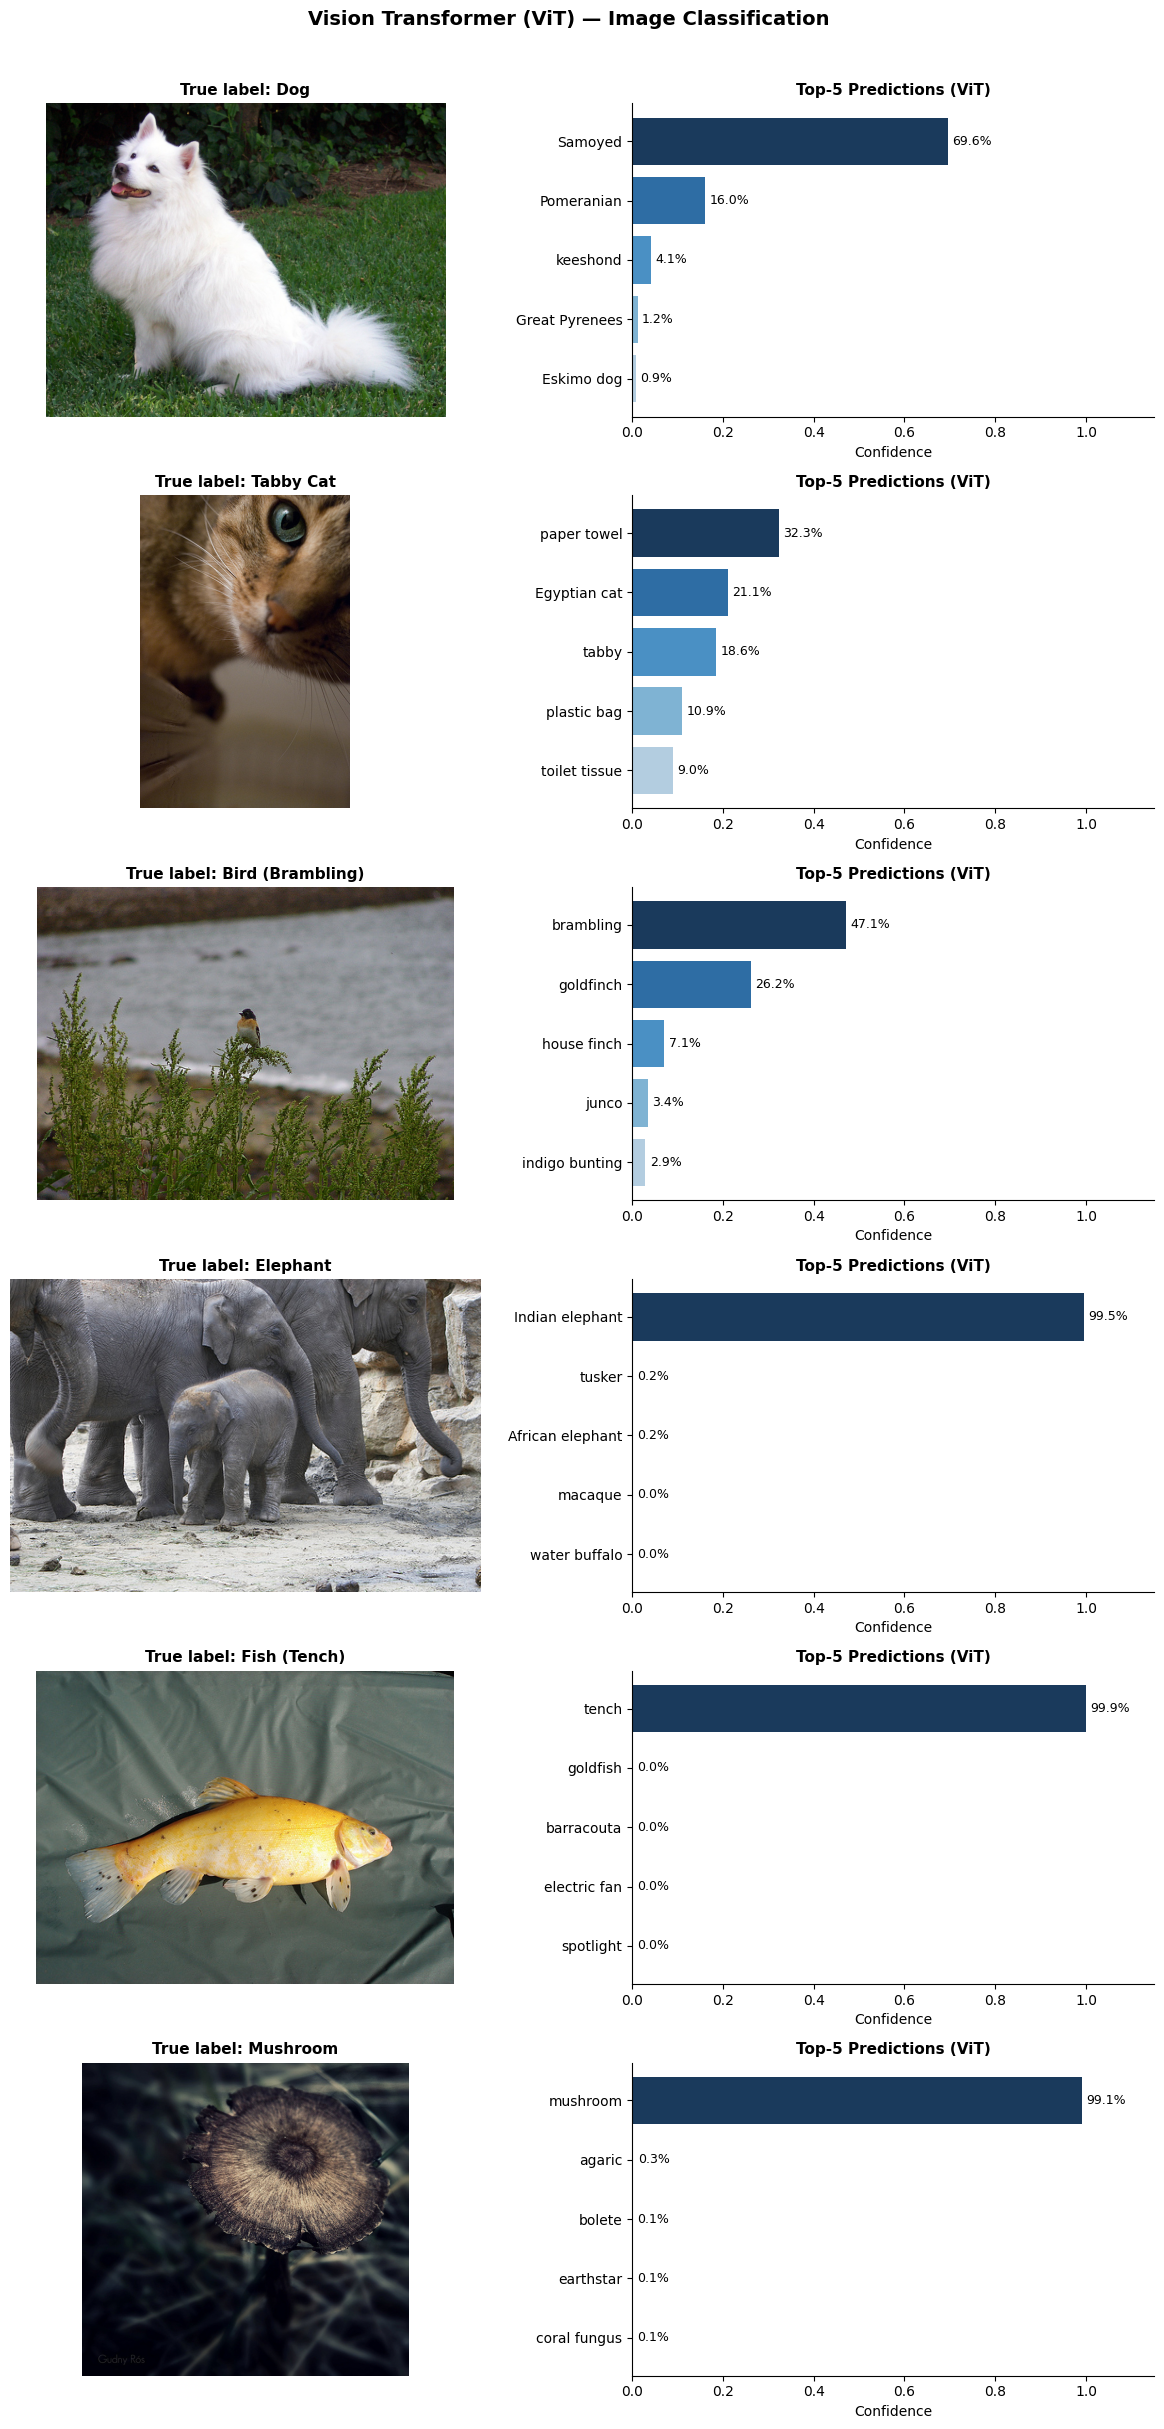


Model: google/vit-base-patch16-224
Transformer self-attention over image patches — same mechanism as BERT over word tokens.


In [ ]:
from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# ── Load the ViT image classification pipeline ────────────────────────────────
# google/vit-base-patch16-224 is pre-trained on ImageNet-21k and fine-tuned on
# ImageNet-1k (1000 classes).
# patch16  → each image is split into 16×16 pixel patches (treated like tokens)
# 224      → input images are resized to 224×224 pixels
image_classifier = pipeline("image-classification", model="google/vit-base-patch16-224")

# ── Public image URLs (GitHub raw — no auth required) ─────────────────────────
# Source 1: pytorch/hub official test images
# Source 2: EliSchwartz/imagenet-sample-images — one real photo per ImageNet class
test_images = [
    ("https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg",
     "Dog"),
    ("https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02123045_tabby.JPEG",
     "Tabby Cat"),
    ("https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n01530575_brambling.JPEG",
     "Bird (Brambling)"),
    ("https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02504013_Indian_elephant.JPEG",
     "Elephant"),
    ("https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n01440764_tench.JPEG",
     "Fish (Tench)"),
    ("https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n07734744_mushroom.JPEG",
     "Mushroom"),
]

# ── Helper: download image from URL ──────────────────────────────────────────
def load_image_from_url(url):
    """Fetch an image from a URL and return it as a PIL Image."""
    response = requests.get(url, timeout=10)
    response.raise_for_status()
    return Image.open(BytesIO(response.content)).convert("RGB")

# ── Helper: classify one image and display it with a prediction bar chart ─────
def classify_and_plot(img, true_label, ax_img, ax_bar):
    """
    Runs ViT on a PIL Image and renders:
      - Left  (ax_img) : the actual photo
      - Right (ax_bar) : horizontal bar chart of top-5 confidence scores
    """
    # Run the pipeline — returns a list of dicts: [{label, score}, ...]
    results = image_classifier(img, top_k=5)

    # ── Left panel: show the image ────────────────────────────────────────────
    ax_img.imshow(img)
    ax_img.set_title(f"True label: {true_label}", fontsize=11, fontweight="bold")
    ax_img.axis("off")

    # ── Right panel: horizontal bar chart ────────────────────────────────────
    # Reverse order so highest-confidence bar appears at the top
    labels = [r["label"].split(",")[0] for r in reversed(results)]  # shorten long ImageNet names
    scores = [r["score"]               for r in reversed(results)]

    colors = ["#1A3A5C", "#2E6DA4", "#4A90C4", "#7FB3D3", "#B3CDE0"]
    bars   = ax_bar.barh(labels, scores, color=colors[::-1])

    # Annotate each bar with its confidence percentage
    for bar, score in zip(bars, scores):
        ax_bar.text(
            score + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{score:.1%}",
            va="center", fontsize=9
        )

    ax_bar.set_xlim(0, 1.15)
    ax_bar.set_xlabel("Confidence", fontsize=10)
    ax_bar.set_title("Top-5 Predictions (ViT)", fontsize=11, fontweight="bold")
    ax_bar.spines[["top", "right"]].set_visible(False)

# ── Plot all images: one row per image ───────────────────────────────────────
n         = len(test_images)
fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))

fig.suptitle("Vision Transformer (ViT) — Image Classification",
             fontsize=14, fontweight="bold", y=1.01)

for i, (url, label) in enumerate(test_images):
    try:
        img = load_image_from_url(url)
        classify_and_plot(img, label, axes[i][0], axes[i][1])
    except Exception as e:
        print(f"Could not load '{label}': {e}")

plt.tight_layout()
plt.show()

print(f"\nModel: {image_classifier.model.name_or_path}")
print("Transformer self-attention over image patches — same mechanism as BERT over word tokens.")

In [ ]:
# ── Model info ────────────────────────────────────────────────────────────────
print("Model used:", image_classifier.model.name_or_path)
print()
print("This demonstrates that the Transformer attention mechanism is domain-agnostic.")
print("The same architecture that reads text can also 'read' image patches.")


Model used: google/vit-base-patch16-224

This demonstrates that the Transformer attention mechanism is domain-agnostic.
The same architecture that reads text can also 'read' image patches.


## Conclusion

In this notebook we covered a broad range of Transformer applications across text and vision:

| Section | Task | Model Type | Pipeline / Library |
|---------|------|------------|--------------------|
| 3.1 | Text Classification (Sentiment) | Encoder-only | `pipeline("sentiment-analysis")` |
| 3.2 | Question Answering | Encoder-only | `pipeline("question-answering")` |
| 3.3 | Text Generation | Decoder-only | `pipeline("text-generation")` |
| 5   | Semantic Similarity | Sentence Transformer | `SentenceTransformer` |
| 6   | Text Clustering | Sentence Transformer | `SentenceTransformer` + KMeans |
| 6   | Named Entity Recognition | Encoder-only | `pipeline("ner")` |
| 7   | Text Summarization | Encoder-Decoder |  |
| 8   | Zero-Shot Classification | Encoder-Decoder (NLI) | `pipeline("zero-shot-classification")` |
| 9   | Machine Translation | Encoder-Decoder | |
| 10  | Fill-Mask (MLM) | Encoder-only | `pipeline("fill-mask")` |
| 11  | Image Classification (ViT) | Encoder-only (vision) | `pipeline("image-classification")` |

**Key takeaways:**
- **Encoder-only models** (BERT, RoBERTa) excel at understanding and classification tasks.
- **Decoder-only models** (GPT-2) are best for open-ended text generation.
- **Encoder-decoder models** (BART, T5, Helsinki-NLP) handle sequence-to-sequence tasks: summarisation, translation, and zero-shot NLI.
- **Sentence Transformers** produce dense embeddings optimised for similarity, clustering, and retrieval.
- **Vision Transformers (ViT)** show that the attention mechanism generalises beyond language to image patches.

---